# intra_dbscan, faster

The pipeline of `intra_dbscan.ipynb`, with faster versions of its heavy steps running next to kairo's own. Every heavy step runs both versions, times them and checks that they give the same result. kairo itself is not changed.

Where the speed comes from:

- **Reading**: pm4py's Rust importer (`r4pm`) instead of its Python one.
- **Features, standardizing, PCA**: tensor operations in torch, on a CUDA GPU, the Apple GPU (MPS) or the CPU, whichever the machine has.
- **k-distance curve**: computed on the distinct rows, each weighted by how often it occurs, instead of on every event. The curve is the same, but the work no longer grows with the square of the log.
- **DBSCAN**: the distinct rows are found once instead of twice.

The steps after DBSCAN are kairo's, they take well under a second. Set the log, `SCALE` (repeats the log for a bigger test) and the device in the next cell. The table at the end compares the timings.

In [1]:
import importlib.util
import time
import types
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import pm4py
import torch
from dotenv import load_dotenv
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

import kairo
from kairo.analysis import META

warnings.filterwarnings("ignore")
load_dotenv(Path("../..") / ".env")

# the log and its columns, as in intra_dbscan.ipynb
LOG_PATH = "../../data/drifted_logs/time_fast/sudden/bank_account_closure/bank_account_closure_time_fast_x05_sudden.xes"
COLUMNS = dict(case_id="case:concept:name", activity="concept:name", timestamp="time:timestamp",
               start_timestamp="start:timestamp", resource="org:resource")

# the log repeated this many times, every copy with its own cases and later in time
SCALE = 1

# kairo's versions next to the fast ones. kairo's k-distance grows with the square of the log,
# on millions of events it runs for hours
RUN_KAIRO = True
RUN_KAIRO_K_DISTANCE = True
RUN_LLM = False

# the pipeline parameters of intra_dbscan.ipynb
WINDOW = 1
SCALING = "minmax"
COMPONENTS = 50
CUT = 15
MIN_SAMPLES = 234
EPS = 0.7
DISTANCE = "manhattan"
CASE_ID = "case_000001"
MAX_CASES = 10
DRIFT_WINDOW = "30D"
DIVERGENCE, REFERENCE, LOOKBACK = "kl", "previous", 5

# a cuda gpu when there is one, else the apple gpu, else the cpu. apple gpus have no float64,
# the others keep kairo's precision
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
DTYPE = torch.float32 if DEVICE.type == "mps" else torch.float64
print(f"torch {torch.__version__} on {DEVICE} with {DTYPE}")

torch 2.12.0 on mps with torch.float32


In [2]:
TIMES = []
CHECKS = {}


def timed(step: str, version: str, fn):
    start = time.perf_counter()
    result = fn()
    TIMES.append({"step": step, "version": version, "seconds": time.perf_counter() - start})
    return result


def max_difference(a: pd.DataFrame, b: pd.DataFrame) -> float:
    # the largest gap between two tables with the same columns, meta columns left out
    columns = [c for c in a.columns if c not in META]
    return float(np.abs(a[columns].to_numpy() - b[columns].to_numpy()).max())


def scale_log(log: pd.DataFrame, times: int) -> pd.DataFrame:
    # the log repeated, every copy with its own case ids and moved behind the copy before
    span = log["time:timestamp"].max() - log["time:timestamp"].min()
    copies = [log]

    for k in range(1, times):
        copy = log.copy()
        copy["case:concept:name"] = copy["case:concept:name"].astype(str) + f"_{k}"
        for column in ["time:timestamp", "start_timestamp"]:
            if column in copy.columns and pd.api.types.is_datetime64_any_dtype(copy[column]):
                copy[column] = copy[column] + k * span
        copies.append(copy)

    return pd.concat(copies, ignore_index=True)

## Faster versions

In [3]:
ROLE_NAMES = {
    "case_id": "case:concept:name", "activity": "concept:name", "timestamp": "time:timestamp",
    "event_id": "event_id", "start_timestamp": "start_timestamp", "resource": "org:resource",
    "event_duration": "event_duration",
}


def read_xes(path: str, variant: str, **columns) -> pd.DataFrame:
    # pm4py with the importer named, then the columns renamed the way kairo.read_log does
    log = pm4py.read_xes(path, variant=variant)
    return log.rename(columns={column: ROLE_NAMES[role] for role, column in columns.items() if column})


# the rust importer pm4py uses when r4pm, or rustxes as its fallback, is installed
RUST = next((name for name in ("r4pm", "rustxes") if importlib.util.find_spec(name)), None)
print("rust importer:", RUST or "not installed, pip install r4pm polars")

rust importer: r4pm


In [4]:
def fast_features_intra(log: pd.DataFrame, sliding_window_size: int = 0) -> pd.DataFrame:
    # the six feature groups of kairo.compute_features_intra as tensor operations. the events
    # are sorted by case and inside a case by time, so every case is one block of rows, and a
    # running sum inside a case is the running sum over all rows minus the one before its start
    case_codes, _ = pd.factorize(log["case:concept:name"])
    act_codes, activities = pd.factorize(log["concept:name"], sort=True)

    # sorted on the timestamps as numbers, as objects they would take seconds. lexsort is
    # stable, so events at the same time keep their order in the log, as they do in kairo
    order = np.lexsort((log["time:timestamp"].astype("int64").to_numpy(), case_codes))

    n, a = len(order), len(activities)
    case = torch.as_tensor(case_codes[order], device=DEVICE)
    act = torch.as_tensor(act_codes[order], device=DEVICE)
    rows = torch.arange(n, device=DEVICE)

    new_case = torch.ones(n, dtype=torch.bool, device=DEVICE)
    new_case[1:] = case[1:] != case[:-1]
    start = torch.cummax(torch.where(new_case, rows, 0), 0).values
    position = rows - start
    length = torch.bincount(case)[case]

    def running_sum(x):
        # counts are summed as integers, a float sum over millions of rows loses exactness
        total = torch.cumsum(x, 0)
        return total - torch.where((start > 0)[:, None], total[start - 1], 0)

    one_hot = torch.nn.functional.one_hot(act, a).to(torch.int32)
    counts = running_sum(one_hot)

    # directly follows pairs, numbered like kairo's columns, which come sorted as text
    has_previous = position > 0
    pair = act.roll(1) * a + act
    pair_codes = torch.unique(pair[has_previous]).cpu().numpy()
    pair_names = np.array([f"{activities[p // a]} -> {activities[p % a]}" for p in pair_codes])
    sorted_pairs = np.argsort(pair_names)
    column = torch.zeros(a * a, dtype=torch.long, device=DEVICE)
    column[torch.as_tensor(pair_codes[sorted_pairs], device=DEVICE)] = torch.arange(len(pair_codes), device=DEVICE)
    pair_hot = torch.nn.functional.one_hot(column[pair], len(pair_codes)).to(torch.int32) * has_previous[:, None]

    blocks = [
        counts.to(DTYPE) / (position + 1)[:, None],
        running_sum(pair_hot),
        counts > 0,
        ((position + 1).to(DTYPE) / length)[:, None],
        one_hot,
    ]
    names = ([f"act_freqs:{x}" for x in activities] + [f"df_counts:{p}" for p in pair_names[sorted_pairs]]
             + [f"act_set:{x}" for x in activities] + ["case_progress"] + [f"current_act:{x}" for x in activities])

    for lag in range(1, sliding_window_size + 1):
        blocks.append(one_hot[(rows - lag).clamp(min=0)] * (position >= lag)[:, None])
        names += [f"past_acts_{lag}:{x}" for x in activities]

    values = torch.cat([block.to(DTYPE) for block in blocks], 1).cpu().numpy()

    # back into the order the log came in, as kairo returns it
    in_log_order = np.empty_like(values)
    in_log_order[order] = values

    return pd.concat([log[META], pd.DataFrame(in_log_order, index=log.index, columns=names)], axis=1)

In [5]:
def fast_standardize(features: pd.DataFrame, method: str, exclude: list = ["current_act", "past_acts", "act_set"]) -> pd.DataFrame:
    columns = [c for c in features.columns if c not in META and not c.startswith(tuple(exclude))]
    x = torch.as_tensor(features[columns].to_numpy(), dtype=DTYPE, device=DEVICE)

    if method == "zscore":
        scaled = (x - x.mean(0)) / x.std(0)
    elif method == "minmax":
        scaled = (x - x.min(0).values) / (x.max(0).values - x.min(0).values)
    else:
        raise ValueError(f"Unknown method: {method}, pick zscore or minmax")

    # a column that never changes has no spread, the division leaves it empty
    result = features.copy()
    result[columns] = torch.nan_to_num(scaled, nan=0.0).cpu().numpy()

    return result


def fast_compute_pca(feature_matrix: pd.DataFrame, num_components: int):
    # the covariance matrix, the heavy part with millions of rows, is built on the device. the
    # eigenvectors of that small square matrix on the cpu, the way sklearn's covariance_eigh does
    names = [c for c in feature_matrix.columns if c not in META]
    x = torch.as_tensor(feature_matrix[names].to_numpy(), dtype=DTYPE, device=DEVICE)
    mean = x.mean(0)
    centered = x - mean
    covariance = (centered.T @ centered).cpu().double().numpy() / (len(x) - 1)

    values, vectors = np.linalg.eigh(covariance)
    values = np.clip(values[::-1], 0, None)
    components = vectors[:, ::-1][:, :num_components].T

    # sklearn's sign rule: the largest entry of every component is positive
    signs = np.sign(components[np.arange(num_components), np.abs(components).argmax(1)])

    # the attributes kairo's plots and abstractions read from a fitted pca
    return types.SimpleNamespace(
        mean_=mean.cpu().double().numpy(),
        components_=components * signs[:, None],
        explained_variance_ratio_=values[:num_components] / values.sum(),
        n_components_=num_components,
        n_features_in_=len(names),
        feature_names_in_=np.array(names, dtype=object),
    )


def fast_apply_pca(feature_matrix: pd.DataFrame, pca, cut_component: int) -> pd.DataFrame:
    x = torch.as_tensor(feature_matrix[list(pca.feature_names_in_)].to_numpy(), dtype=DTYPE, device=DEVICE)
    mean = torch.as_tensor(pca.mean_, dtype=DTYPE, device=DEVICE)
    components = torch.as_tensor(pca.components_[:cut_component], dtype=DTYPE, device=DEVICE)

    compressed = pd.DataFrame(
        ((x - mean) @ components.T).cpu().numpy(),
        index=feature_matrix.index,
        columns=[f"pc_{i + 1}" for i in range(cut_component)],
    )

    return pd.concat([feature_matrix[[c for c in META if c in feature_matrix.columns]], compressed], axis=1)

In [6]:
def distinct_rows(df: pd.DataFrame):
    # the distinct rows, which of them every row is, and how often each occurs. on a cuda gpu
    # when there is one, the apple gpu is many times slower at this than the cpu
    device = DEVICE if DEVICE.type == "cuda" else torch.device("cpu")
    data = torch.as_tensor(df.drop(columns=META, errors="ignore").to_numpy(), device=device)
    rows, inverse, counts = torch.unique(data, dim=0, return_inverse=True, return_counts=True)

    return rows.cpu().numpy(), inverse.cpu().numpy(), counts.cpu().numpy()


def fast_k_distances(df: pd.DataFrame, min_samples: int = 5, distance: str = "euclidean"):
    # every distinct row once, with how often it occurs. its k-distance is the distance at which
    # its own copies plus its nearest distinct rows add up to min_samples rows, as dbscan counts
    rows, _, counts = distinct_rows(df)
    neighbours = NearestNeighbors(n_neighbors=min(min_samples, len(rows)), metric=distance).fit(rows)
    distances, indices = neighbours.kneighbors(rows)
    first = (np.cumsum(counts[indices], axis=1) >= min_samples).argmax(axis=1)

    return distances[np.arange(len(rows)), first], counts


def fast_plot_k_distance(k_distances: np.ndarray, counts: np.ndarray, min_samples: int):
    # one step per distinct row, the x axis still counts every row
    order = np.argsort(k_distances)

    return px.line(
        x=np.cumsum(counts[order]),
        y=k_distances[order],
        line_shape="hv",
        labels={"x": "Rows sorted by k-distance", "y": "k-distance"},
        title=f"DBSCAN k-distance curve (k = min_samples = {min_samples})",
    )


def fast_dbscan(df: pd.DataFrame, eps: float = 0.5, min_samples: int = 5, distance: str = "euclidean"):
    # the distinct rows are found once, and their clusters go back to every row
    rows, inverse, counts = distinct_rows(df)
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=distance).fit(rows, sample_weight=counts)

    return dbscan, pd.DataFrame({"cluster": dbscan.labels_[inverse]}, index=df.index)

## Pipeline

In [7]:
# kairo.read_log uses the rust importer by itself once r4pm is installed, so the python one
# is named here to have something to compare with
if RUN_KAIRO or RUST is None:
    python_log = timed("read", "kairo", lambda: read_xes(LOG_PATH, "chunk_regex", **COLUMNS))

if RUST:
    log = timed("read", "fast", lambda: read_xes(LOG_PATH, RUST, **COLUMNS))
    if RUN_KAIRO:
        CHECKS["read"] = f"same log: {log[python_log.columns].equals(python_log)}"
else:
    log = python_log

log = scale_log(log, SCALE)
print(f"{len(log):,} events, {log['case:concept:name'].nunique():,} cases")
log.head()

212,721 events, 32,429 cases


,CLOSURE_REASON,time:timestamp,org:role,start_timestamp,lifecycle:transition,org:resource,concept:name,CLOSURE_TYPE,case:concept:name
0,1 - Client lost,2017-05-29 08:49:25+00:00,APPLICANT,2017-05-29 08:47:46+00:00,complete,6,Request created,Client Recess,case_000000
1,1 - Client lost,2017-05-29 08:52:49+00:00,DIRECTOR,2017-05-29 08:49:25+00:00,complete,7,Evaluating Request (NO registered letter),Client Recess,case_000000
2,1 - Client lost,2017-05-29 09:02:39+00:00,APPLICANT,2017-05-29 08:56:04+00:00,complete,7,Service closure Request with network responsib...,Client Recess,case_000000
3,1 - Client lost,2017-05-29 11:23:33+00:00,BACK-OFFICE,2017-05-29 09:02:39+00:00,complete,BOF,Service closure Request with BO responsibility,Client Recess,case_000000
4,1 - Client lost,2017-05-31 09:26:08+00:00,APPLICANT,2017-05-29 11:23:33+00:00,complete,7,Network Adjustment Requested,Client Recess,case_000000


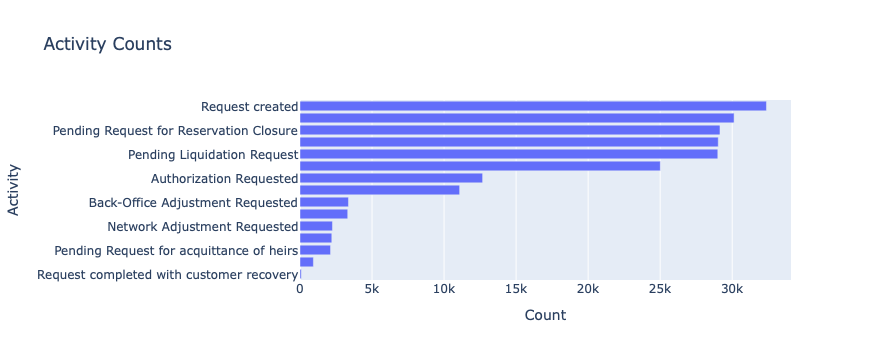

In [8]:
stats = timed("log stats", "kairo", lambda: kairo.compute_log_stats(log))
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [9]:
if RUN_KAIRO:
    kairo_features = timed("features", "kairo", lambda: kairo.compute_features_intra(log, sliding_window_size=WINDOW))

features = timed("features", "fast", lambda: fast_features_intra(log, WINDOW))

if RUN_KAIRO:
    CHECKS["features"] = (f"same columns: {features.columns.equals(kairo_features.columns)}, "
                          f"largest gap {max_difference(features, kairo_features):.1e}")
features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
if RUN_KAIRO:
    kairo_std = timed("standardize", "kairo", lambda: kairo.standardize(kairo_features, method=SCALING))

std_features = timed("standardize", "fast", lambda: fast_standardize(features, SCALING))

if RUN_KAIRO:
    CHECKS["standardize"] = f"largest gap {max_difference(std_features, kairo_std):.1e}"
std_features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.4,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


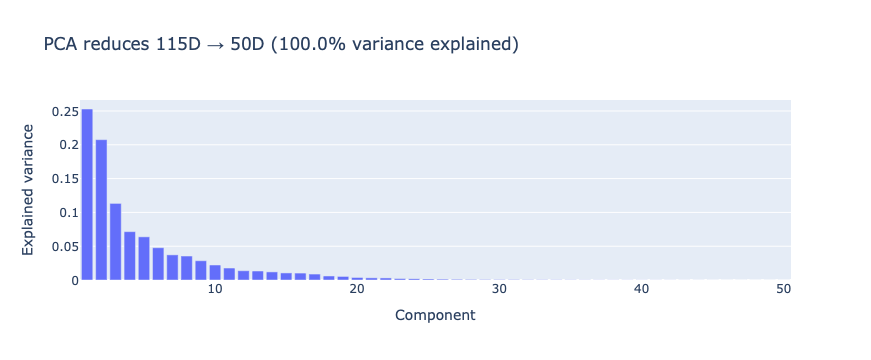

In [11]:
if RUN_KAIRO:
    kairo_pca = timed("pca fit", "kairo", lambda: kairo.compute_pca(kairo_std, num_components=COMPONENTS))

pca = timed("pca fit", "fast", lambda: fast_compute_pca(std_features, COMPONENTS))

if RUN_KAIRO:
    gap = np.abs(pca.explained_variance_ratio_ - kairo_pca.explained_variance_ratio_).max()
    CHECKS["pca fit"] = f"explained variances, largest gap {gap:.1e}"

pca_plot = kairo.plot_pca_variances(pca)
pca_plot.show()

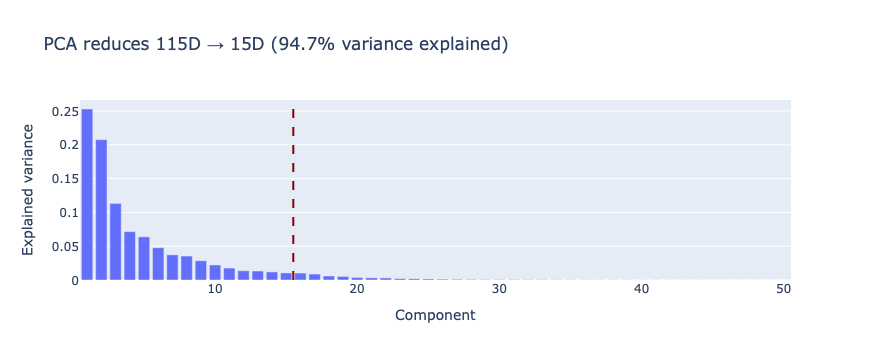

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,pc_12,pc_13,pc_14,pc_15
0,case_000000,2017-05-29 08:49:25+00:00,-1.479990,-0.393455,-0.803889,-0.225303,-0.178529,0.327242,-0.501432,-0.215670,-0.267271,-0.115836,-0.059156,0.025086,-0.085789,-0.040241,0.003012
1,case_000000,2017-05-29 08:52:49+00:00,-1.448552,0.484034,-0.116427,0.223079,0.198962,-0.509631,-0.131735,1.075068,0.750334,-0.464403,0.361061,-0.132706,-0.290549,-0.059900,0.000419
2,case_000000,2017-05-29 09:02:39+00:00,-1.057345,0.903371,0.711988,0.627997,0.498049,-0.749164,-0.222379,-0.145606,-0.694494,0.391442,0.597276,-0.118115,0.308941,0.224336,-0.046806
3,case_000000,2017-05-29 11:23:33+00:00,-0.501295,1.246954,1.285447,0.374430,0.154014,1.041552,0.080661,0.028617,0.184666,0.144775,-0.177327,0.085106,-0.113697,0.087434,-0.069063
4,case_000000,2017-05-31 09:26:08+00:00,-0.341882,1.248738,1.148389,-0.147344,-0.371278,0.088745,-0.141291,0.058526,-0.137767,-0.144888,0.056315,0.737970,-0.191353,0.312047,1.088192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,-1.200792,-0.270186,-0.661586,-0.035463,-0.046256,-0.267127,0.531418,0.570925,0.551736,-0.054681,-0.613464,0.875305,1.653417,-0.220426,-0.038467
212717,case_032427,2019-03-06 15:01:31+00:00,-1.390101,-0.359150,-0.812277,-0.225946,-0.194729,0.323119,-0.469115,-0.200922,-0.239354,-0.088858,-0.059781,0.086459,0.030797,-0.059359,0.000535
212718,case_032427,2019-03-06 15:01:31+00:00,-1.200792,-0.270186,-0.661586,-0.035463,-0.046256,-0.267127,0.531418,0.570925,0.551736,-0.054681,-0.613464,0.875305,1.653417,-0.220426,-0.038467
212719,case_032428,2019-03-06 16:38:59+00:00,-1.390101,-0.359150,-0.812277,-0.225946,-0.194729,0.323119,-0.469115,-0.200922,-0.239354,-0.088858,-0.059781,0.086459,0.030797,-0.059359,0.000535


In [12]:
if RUN_KAIRO:
    kairo_compressed = timed("pca apply", "kairo", lambda: kairo.apply_pca(kairo_std, kairo_pca, cut_component=CUT))

compressed_features = timed("pca apply", "fast", lambda: fast_apply_pca(std_features, pca, CUT))

if RUN_KAIRO:
    CHECKS["pca apply"] = f"largest gap {max_difference(compressed_features, kairo_compressed):.1e}"

pca_plot_cut = kairo.plot_pca_variances(pca, cut_component=CUT)
pca_plot_cut.show()
compressed_features

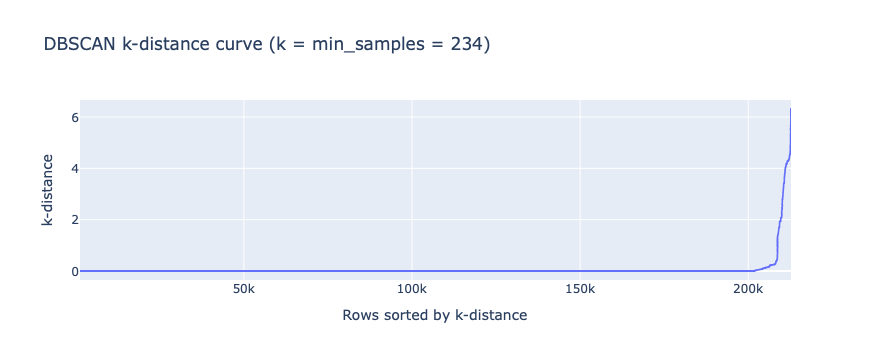

In [13]:
if RUN_KAIRO and RUN_KAIRO_K_DISTANCE:
    kairo_k_plot = timed("k-distance", "kairo", lambda: kairo.plot_dbscan_k_distance(
        kairo_compressed, min_samples=MIN_SAMPLES, distance=DISTANCE))

k_distances, counts = timed("k-distance", "fast", lambda: fast_k_distances(compressed_features, MIN_SAMPLES, DISTANCE))

if RUN_KAIRO and RUN_KAIRO_K_DISTANCE:
    gap = np.abs(np.sort(np.repeat(k_distances, counts)) - np.sort(kairo_k_plot.data[0].y)).max()
    CHECKS["k-distance"] = f"largest gap between the curves {gap:.1e}"

k_distances_plot = fast_plot_k_distance(k_distances, counts, MIN_SAMPLES)
k_distances_plot.show()

In [14]:
if RUN_KAIRO:
    def kairo_dbscan():
        model = kairo.compute_dbscan(kairo_compressed, min_samples=MIN_SAMPLES, eps=EPS, distance=DISTANCE)
        return model, kairo.get_dbscan_clusters(kairo_compressed, model)

    kairo_model, kairo_clusters = timed("dbscan", "kairo", kairo_dbscan)

dbscan, clusters = timed("dbscan", "fast", lambda: fast_dbscan(compressed_features, EPS, MIN_SAMPLES, DISTANCE))

if RUN_KAIRO:
    same = (clusters["cluster"].to_numpy() == kairo_clusters["cluster"].to_numpy()).all()
    ari = adjusted_rand_score(kairo_clusters["cluster"], clusters["cluster"])
    CHECKS["dbscan"] = f"same labels: {same}, adjusted rand index {ari:.4f}"
clusters

,cluster
0,0
1,1
2,5
3,11
4,14
...,...
212716,4
212717,0
212718,4
212719,0


The steps from here on are kairo's, on the results of the fast steps.

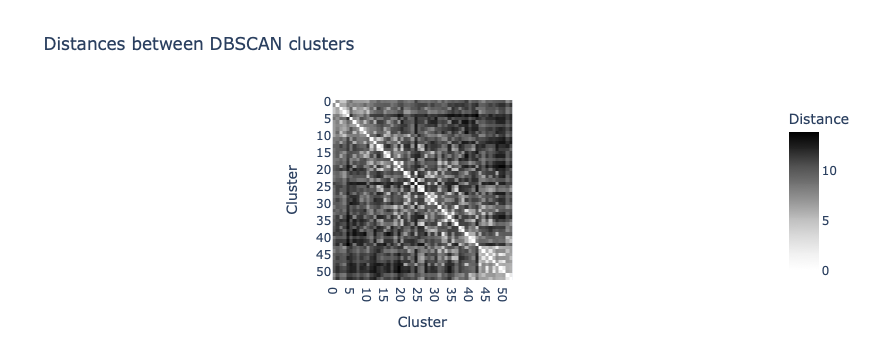

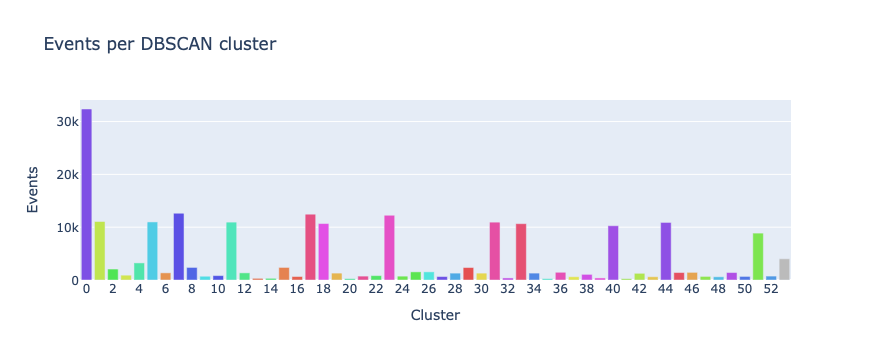

In [15]:
features_and_clusters = pd.concat([compressed_features, clusters], axis=1)

state_distances = timed("state distances", "kairo", lambda: kairo.get_dbscan_state_distances(dbscan))
state_freqs = timed("state frequencies", "kairo", lambda: kairo.get_dbscan_state_frequencies(features_and_clusters))
color_mapping = kairo.compute_dbscan_color_mapping(dbscan)

distances_plot = kairo.plot_dbscan_distances(state_distances)
distances_plot.show()

freqs_plot = kairo.plot_dbscan_frequencies(state_freqs, color_mapping)
freqs_plot.show()

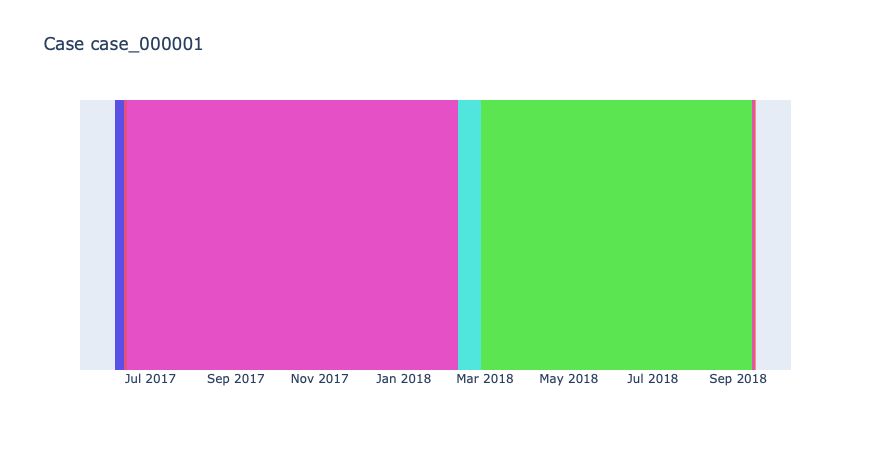

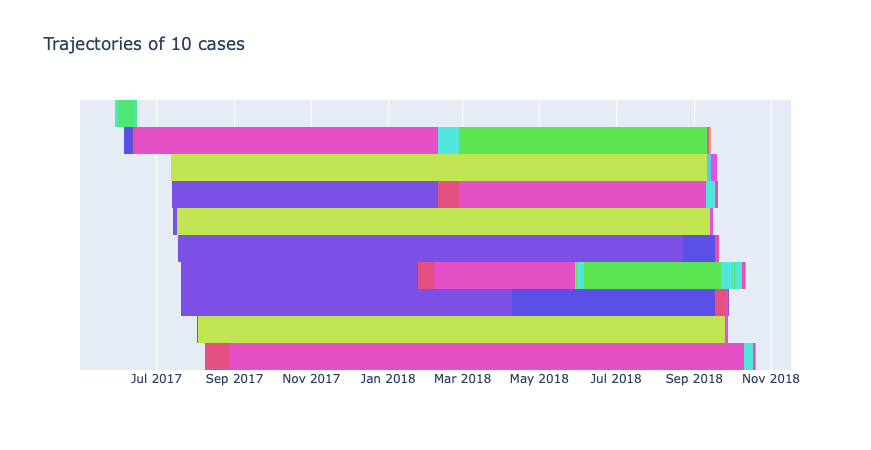

In [16]:
case_trajectory = timed("case trajectory", "kairo", lambda: kairo.get_dbscan_case_trajectory(features_and_clusters, case_id=CASE_ID))
case_trajectory_plot = kairo.plot_dbscan_case_trajectory(case_trajectory, color_mapping, case_id=CASE_ID)
case_trajectory_plot.show()

case_trajectories = timed("trajectories", "kairo", lambda: kairo.get_dbscan_trajectories(features_and_clusters, max_cases=MAX_CASES))
case_trajectories_plot = kairo.plot_dbscan_trajectories(case_trajectories, color_mapping)
case_trajectories_plot.show()

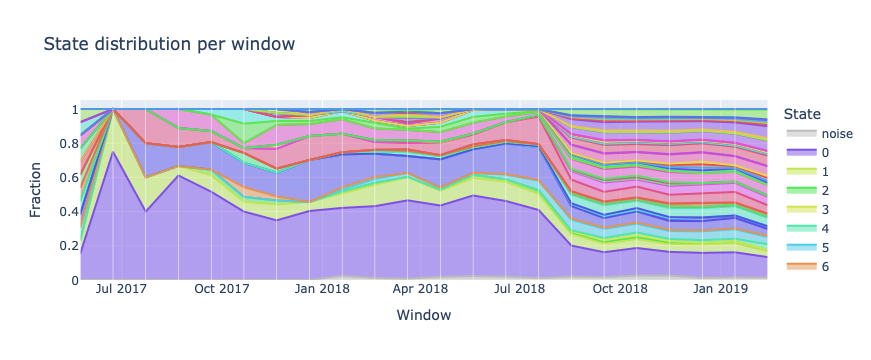

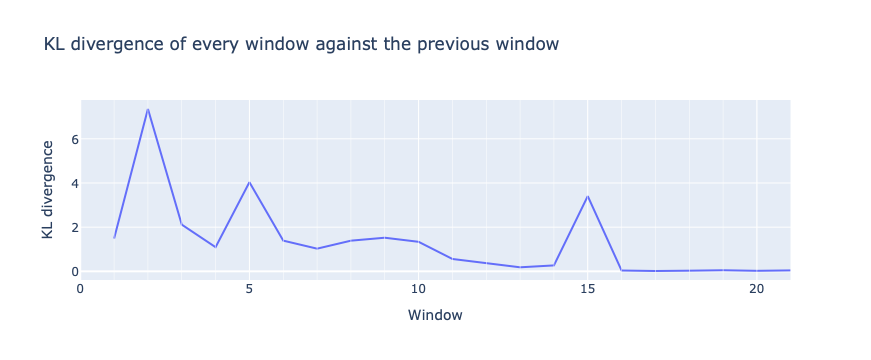

In [17]:
freq_distributions = timed("distributions", "kairo", lambda: kairo.compute_state_distributions(features_and_clusters, window=DRIFT_WINDOW))
distributions_plot = kairo.plot_state_distributions(freq_distributions, color_mapping)
distributions_plot.show()

divergences = timed("divergences", "kairo", lambda: kairo.compute_divergences(freq_distributions, DIVERGENCE, REFERENCE, LOOKBACK))
divergences_plot = kairo.plot_divergences(divergences, DIVERGENCE, REFERENCE)
divergences_plot.show()

In [18]:
abstractions = timed("abstractions", "kairo", lambda: [
    kairo.abstract_log_stats(stats),
    kairo.abstract_features(features),
    kairo.abstract_pca(pca, cut_component=CUT),
    kairo.abstract_states(state_freqs, state_distances, color_mapping),
    kairo.abstract_case_trajectory(case_trajectory, CASE_ID),
    kairo.abstract_case_trajectories(case_trajectories),
    kairo.abstract_distributions(freq_distributions),
    kairo.abstract_divergences(divergences, DIVERGENCE, REFERENCE, LOOKBACK),
])
print("\n\n".join(abstractions))

Event log: 212,721 events of 32,429 cases, 15 activities and 654 resources, from 2017-05-29 08:49:25+00:00 to 2019-03-06 16:38:59+00:00.
Throughput time per case in days: min 0.00, mean 13.46, median 6.07, max 503.59.
Events per case: min 2, mean 6.6, median 7.0, max 23.
Events per activity: Request created (32,377), Service closure Request with BO responsibility (30,130), Pending Request for Reservation Closure (29,151), Request completed with account closure (29,031), Pending Liquidation Request (29,000), Service closure Request with network responsibility (25,009), Authorization Requested (12,675), Evaluating Request (NO registered letter) (11,080), Back-Office Adjustment Requested (3,363), Request deleted (3,312), Network Adjustment Requested (2,252), Evaluating Request (WITH registered letter) (2,207), Pending Request for acquittance of heirs (2,119), Pending Request for Network Information (929), Request completed with customer recovery (86)
Most active resources: BOF (113,958), 

In [19]:
plots = [activity_plot, pca_plot_cut, distances_plot, freqs_plot, case_trajectory_plot,
         case_trajectories_plot, distributions_plot, divergences_plot]
question = "Analyze and summarize the given information. Do not use markdown format, just raw text"

messages = timed("messages, renders the plots", "kairo", lambda: kairo.create_messages(
    provider="custom", system_prompt=kairo.DEFAULT_SYSTEM_PROMPT, prompts=abstractions + [question], plots=plots))
num_tokens = kairo.count_input_tokens(provider="custom", messages=messages)
print(f"about {num_tokens:,} input tokens")

if RUN_LLM:
    llm = kairo.LLMConnector(provider="custom", model="Qwen/Qwen3-VL-32B-Instruct", base_url="http://137.226.117.70:8000/v1")
    response = timed("llm answer", "kairo", lambda: llm.call(messages=messages, max_tokens=64000))
    print(kairo.count_output_tokens("custom", response), "output tokens")
    print(kairo.get_response_text(response))

about 11,211 input tokens


## Comparison

In [20]:
table = pd.DataFrame(TIMES).pivot_table(index="step", columns="version", values="seconds", aggfunc="sum", sort=False)

if "kairo" in table and "fast" in table:
    table["faster"] = table["kairo"] / table["fast"]

table["same result"] = table.index.map(CHECKS)
print(f"{len(log):,} events on {DEVICE} with {DTYPE}")
table.round(2)

212,721 events on mps with torch.float32


version,kairo,fast,faster,same result
step,,,,
read,2.37,0.39,6.10,same log: True
log stats,0.04,NaN,NaN,NaN
features,0.25,0.20,1.21,"same columns: True, largest gap 2.9e-08"
standardize,0.05,0.03,1.54,largest gap 7.2e-08
pca fit,0.02,0.02,0.97,"explained variances, largest gap 1.5e-07"
pca apply,0.03,0.02,1.39,largest gap 5.0e-05
k-distance,18.02,0.17,105.05,largest gap between the curves 9.4e-05
dbscan,0.60,0.15,3.99,"same labels: True, adjusted rand index 1.0000"
state distances,0.00,NaN,NaN,NaN
